# 📘 Methods Summary for Wilcoxon Analysis and Sniffing Pie Plots

## 🧪 Wilcoxon Signed-Rank Unit Firing Analysis

### **Event Window Definitions**
- **Event window:** 3 seconds starting at the onset of each behavioral bout  
- **Baseline window:** 3 seconds immediately before the event onset  
- **Offset:** 0 seconds  
- **Time binning:** 100 ms bins for PSTHs  

### **Bout Cleaning**
Behavioral events were cleaned with:
- `min_iti = 1.0 s` — merge bouts separated by < 1 second  
- `min_bout = 0.5 s` — remove bouts shorter than 0.5 seconds  

A behavior was only analyzed if it had at least **6 cleaned bouts** in that recording.

### **Statistical Testing**
For each unit in every recording:
1. Baseline and event firing rates were extracted.
2. A Wilcoxon signed-rank test compared event vs. baseline firing.
3. Units were categorized as:
   - **Increased firing**
   - **Decreased firing**
   - **Non-significant**

### **Units Included**
- Only **“good” units** (from Phy curation) were included.
- Units must have non-empty spike trains.

### **Sample Size for Wilcoxon Bar Plot**
- **Recordings analyzed:** 8  
- **Mice represented:** 4 (each contributes one d0 and one d7 recording)

This forms the dataset used for the **Day 0 vs Day 7 Wilcoxon bar plot**.

---

## 🥧 Pie Plot (Complete Sniffing Behaviors Only)

The pie plots include only recordings where **all three sniffing behaviors** passed the bout threshold:

- facial sniffing  
- anogenital sniffing  
- sniffing object  

Recordings missing any of these behaviors after cleaning were excluded.

### **Sample Size for Complete-Behavior Pie Plot**
| Day | # Recordings Used | # Mice | Notes |
|-----|-------------------|--------|-------|
| **Day 0** | **2 recordings** | **2 mice** | Only 2 recordings contained all 3 sniffing behaviors with ≥6 cleaned bouts |
| **Day 7** | **4 recordings** | **4 mice** | More complete-behavior recordings available on Day 7 |

### **Neuron Counting (No Double Counting)**
- Neurons are counted **once per recording**, not per behavior.
- Total neurons per day = sum of unique units from each included recording.
- Significant units per behavior = sum of `n_sig` for that behavior across complete recordings.

### **Pie Chart Values**
Slices represent:
- **Percent of neurons significantly modulated** by each sniffing behavior  
- Final slice = **non-significant neurons**

These percentages reflect **how each behavior accounts for significant modulation** within that day’s complete recordings.

---

## ✔ Summary

- **Wilcoxon bar plot** uses the full dataset:  
  - 8 recordings, 4 mice, 3s baseline, 3s event

- **Pie plot** uses the subset of recordings with all 3 sniffing behaviors:  
  - Day 0: 2 recordings (2 mice)  
  - Day 7: 4 recordings (4 mice)  
  - No double-counting of neurons  
  - Shows distribution of significant modulation across sniffing behaviors  



In [45]:
import sys, importlib, os, inspect

NEW_ROOT = "/blue_npadillacoreano/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory"
OLD_ROOT = "/blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis"

os.chdir('/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys') # seems to be the only real fix

import importlib
import pickle

import behavior.boris_extraction as boris
from spike.spike_analysis.spike_collection import SpikeCollection
import trodes.read_exported as tr

import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path


print("behavior package from:", boris.__file__)
print("boris_extraction from:", inspect.getfile(boris))
print("trodes read_exported from: ", inspect.getfile(tr))

rec_subj_dict_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/d0_d7_rec_subj_dict"
event_dict_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/allsubjs_dict_d0_d7.pkl"
phy_recs = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/data_rehouse/phy_recs"

behavior package from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
boris_extraction from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
trodes read_exported from:  /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/trodes/read_exported.py


In [46]:
import spike.spike_analysis.spike_recording as sr
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.normalization as norm
import spike.spike_analysis.single_cell as single_cell
import behavior.behavioral_epoch_tools as betools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import behavior.boris_extraction as boris
import matplotlib.pyplot as plt
import pickle
import re
import seaborn as sns

# Set global seaborn style
sns.set_context("notebook", font_scale=1.9)

# Define color palette for Day 0 (Teal) and Day 7 (Magenta)
COLOR_DAY0 = '#53A1A9'  # Teal
COLOR_DAY7 = '#A95376'  # Magenta

In [47]:
try:
    with open(rec_subj_dict_path, 'rb') as file:
        rec_subj_dict = pickle.load(file)
            
except FileNotFoundError:
    print("filenotfound")
rec_subj_dict

{'22_rehouse_d0_merged.rec': '22',
 '22_rehouse_d7_merged.rec': '22',
 '23_rehouse_d0_merged.rec': '23',
 '23_rehouse_d7_merged.rec': '23',
 '31_rehouse_d0_merged.rec': '31',
 '31_rehouse_d7_merged.rec': '31',
 '32_rehouse_d0_merged.rec': '32',
 '32_rehouse_d7_merged.rec': '32',
 '41_rehouse_d0_merged.rec': '41',
 '41_rehouse_d7_merged.rec': '41',
 '44_rehouse_d0_merged.rec': '44',
 '44_rehouse_d7_merged.rec': '44'}

In [48]:
try:
    with open(event_dict_path, 'rb') as file:
        event_dict = pickle.load(file)
            
except FileNotFoundError:
    print("filenotfound")
print(event_dict.keys())

dict_keys(['22_rehouse_d0_merged.rec', '22_rehouse_d7_merged.rec', '23_rehouse_d0_merged.rec', '23_rehouse_d7_merged.rec', '31_rehouse_d0_merged.rec', '31_rehouse_d7_merged.rec', '32_rehouse_d0_merged.rec', '32_rehouse_d7_merged.rec', '41_rehouse_d0_merged.rec', '41_rehouse_d7_merged.rec', '44_rehouse_d0_merged.rec', '44_rehouse_d7_merged.rec'])


In [49]:
for rec_name, ev_dict in event_dict.items():
    for ev_key, arr in ev_dict.items():
        if not isinstance(arr, np.ndarray):
            print(rec_name, ev_key, type(arr))
        elif arr.ndim != 2 or arr.shape[1] != 2:
            print(rec_name, ev_key, arr.shape)


In [50]:
import os

phy_recs = "/blue/npadillacoreano/t.heeps/npadillacoreano/share/rehouse_data/phy_recs"
for root, dirs, files in os.walk(phy_recs):
    print("ROOT:", root)
    print("DIRS:", dirs)
    break


ROOT: /blue/npadillacoreano/t.heeps/npadillacoreano/share/rehouse_data/phy_recs
DIRS: ['32_rehouse_d2_merged.rec', '32_rehouse_d7_merged.rec', '32_rehouse_d5_merged.rec', '22_rehouse_d7_merged.rec', '44_rehouse_d3_merged.rec', '22_rehouse_d3_merged.rec', '22_rehouse_d4_merged.rec', '44_rehouse_d7_merged.rec', '41_rehouse_d5_merged.rec', '32_rehouse_d4_merged.rec', '41_rehouse_d6_merged.rec', '32_rehouse_d1_merged.rec', '44_rehouse_d4_merged.rec', '31_rehouse_d7_merged.rec', '41_rehouse_d7_merged.rec', '22_rehouse_d6_merged.rec', '44_rehouse_d1_merged.rec', '44_rehouse_d2_merged.rec', '41_rehouse_d4_merged.rec', '41_rehouse_d3_merged.rec', '32_rehouse_d3_merged.rec', '22_rehouse_d2_merged.rec', '23_rehouse_d2_merged.rec', '44_rehouse_d0_merged.rec', '41_rehouse_d2_merged.rec', '22_rehouse_d0_merged.rec', '22_rehouse_d1_merged.rec', '41_rehouse_d1_merged.rec', '32_rehouse_d0_merged.rec', '41_rehouse_d0_merged.rec', '22_rehouse_d5_merged.rec', '44_rehouse_d5_merged.rec', '23_rehouse_d5_me

In [51]:
sc = SpikeCollection(phy_recs, event_dict, rec_subj_dict)

--skipping--
loading  32_rehouse_d7_merged.rec
--skipping--
loading  22_rehouse_d7_merged.rec
--skipping--
--skipping--
--skipping--
loading  44_rehouse_d7_merged.rec
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
loading  31_rehouse_d7_merged.rec
loading  41_rehouse_d7_merged.rec
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
loading  44_rehouse_d0_merged.rec
--skipping--
loading  22_rehouse_d0_merged.rec
--skipping--
--skipping--
loading  32_rehouse_d0_merged.rec
loading  41_rehouse_d0_merged.rec
Unit 163 is unsorted & has 1202 spikes
Unit 163 will be deleted
Unit 153 is unsorted & has 4386 spikes
Unit 153 will be deleted
Unit 157 is unsorted & has 652 spikes
Unit 157 will be deleted
Unit 162 is unsorted & has 34 spikes
Unit 162 will be deleted
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--


In [52]:
sc.analyze(timebin=100)

Your event dictionary keys are different across recordings.
Please double check them:
32_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'sniffing object', 'mice taken out', 'anogenital sniffing', 'facial sniffing'])
22_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'fighting', 'anogenital sniffing', 'facial sniffing', 'mice taken out', 'sniffing object'])
44_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'sniffing object', 'mice taken out', 'anogenital sniffing', 'facial sniffing'])
31_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'fighting', 'mice taken out', 'sniffing object'])
41_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'chasing', 'anogenital sniffing', 'facial sniffing', 'mice taken out', 'sniffing object'])
44_rehouse_d0_merged.rec keys: dict_keys(['mice back in', 'anogenital sniffing', 'facial sniffing', 'mice taken out', 'sniffing object'])
22_rehouse_d0_merged.rec keys: dict_keys(['mice back in', 'sniffing object', 'mice taken out'

In [53]:
import importlib
importlib.reload(sr)
importlib.reload(single_cell)

<module 'spike.spike_analysis.single_cell' from '/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/spike/spike_analysis/single_cell.py'>

In [10]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [11]:
epoch_bins = {}

condition_order = {
    # --- Subject 22 ---
    ("22", "d0"): "OM",
    ("22", "d7"): "MO",

    # --- Subject 23 ---
    ("23", "d0"): "MO",
    ("23", "d7"): "OM",

    # --- Subject 31 ---
    ("31", "d0"): "OM",
    ("31", "d7"): "MO",

    # --- Subject 32 ---
    ("32", "d0"): "MO",
    ("32", "d7"): "OM",

    # --- Subject 41 ---
    ("41", "d0"): "OM",
    ("41", "d7"): "MO",

    # --- Subject 44 ---
    ("44", "d0"): "MO",
    ("44", "d7"): "OM",
}


In [12]:
# ============================================================================
# FILTER RECORDINGS: Keep only subjects with BOTH d0 AND d7
# ============================================================================
print("="*80)
print("FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA")
print("="*80)

# Extract subject IDs and days from all recordings
subjects_by_day = {'d0': set(), 'd7': set()}

for rec in sc.recordings:
    rec_name = rec.name
    # Extract subject number (e.g., "22" from "22_rehouse_d0_merged.rec")
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        
        # Determine day
        if '_d0_' in rec_name or rec_name.endswith('_d0.rec'):
            subjects_by_day['d0'].add(subject_id)
        elif '_d7_' in rec_name or rec_name.endswith('_d7.rec'):
            subjects_by_day['d7'].add(subject_id)

print(f"\nSubjects with d0 recordings: {sorted(subjects_by_day['d0'])}")
print(f"Subjects with d7 recordings: {sorted(subjects_by_day['d7'])}")

# Find subjects that have BOTH d0 and d7
subjects_with_both = subjects_by_day['d0'] & subjects_by_day['d7']
subjects_missing_d0 = subjects_by_day['d7'] - subjects_by_day['d0']
subjects_missing_d7 = subjects_by_day['d0'] - subjects_by_day['d7']

print(f"\n✓ Subjects with BOTH d0 and d7: {sorted(subjects_with_both)}")
if subjects_missing_d0:
    print(f"⚠️ Subjects missing d0 (will be EXCLUDED): {sorted(subjects_missing_d0)}")
if subjects_missing_d7:
    print(f"⚠️ Subjects missing d7 (will be EXCLUDED): {sorted(subjects_missing_d7)}")

# Filter recordings to keep only those from subjects with both days
original_count = len(sc.recordings)
filtered_recordings = []
excluded_recordings = []

for rec in sc.recordings:
    rec_name = rec.name
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        if subject_id in subjects_with_both:
            filtered_recordings.append(rec)
        else:
            excluded_recordings.append(rec_name)
    else:
        # Keep recordings without clear subject ID pattern (shouldn't happen)
        filtered_recordings.append(rec)

# Update the SpikeCollection with filtered recordings
sc.recordings = filtered_recordings

if excluded_recordings:
    print(f"\nExcluded recordings:")
    for rec_name in excluded_recordings:
        print(f"  - {rec_name}")

print(f"\n✓ Analysis will proceed with {len(subjects_with_both)} subjects (paired d0/d7)")
print("="*80)

FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA

Subjects with d0 recordings: ['22', '32', '41', '44']
Subjects with d7 recordings: ['22', '31', '32', '41', '44']

✓ Subjects with BOTH d0 and d7: ['22', '32', '41', '44']
⚠️ Subjects missing d0 (will be EXCLUDED): ['31']

Excluded recordings:
  - 31_rehouse_d7_merged.rec

✓ Analysis will proceed with 4 subjects (paired d0/d7)


In [13]:
# ============================================================================
# STEP 1: Extract Raw Behavioral Events
# ============================================================================
print("="*80)
print("STEP 1: EXTRACTING RAW BEHAVIORAL EVENTS")
print("="*80)

# Define which events to include/exclude
behavioral_events = [
    'facial sniffing',
    'anogenital sniffing', 
    'chasing',
    'fighting',
    'sniffing object'
]

exclude_events = ['mice back in', 'mice taken out']

# Store raw events organized by recording
raw_events_by_recording = {}

for rec in sc.recordings:
    rec_name = rec.name
    
    # Extract subject and day
    subject_match = re.match(r'(\d+)_', rec_name)
    if not subject_match:
        continue
    subject_id = subject_match.group(1)
    
    if '_d0_' in rec_name or rec_name.endswith('_d0.rec'):
        day = 'd0'
    elif '_d7_' in rec_name or rec_name.endswith('_d7.rec'):
        day = 'd7'
    else:
        continue
    
    print(f"\n{rec_name} (Subject {subject_id}, {day.upper()})")
    
    # Initialize storage for this recording
    raw_events_by_recording[rec_name] = {
        'subject': subject_id,
        'day': day,
        'events': {},
        'event_counts': {}
    }
    
    # Extract events from event_dict
    for event_name in rec.event_dict.keys():
        # Skip excluded events
        if event_name in exclude_events:
            continue
        
        # Get event windows (list of [start_ms, stop_ms])
        event_windows = rec.event_dict[event_name]
        
        if len(event_windows) > 0:
            # Convert to seconds for easier processing
            event_windows_sec = np.array([[start/1000, stop/1000] for start, stop in event_windows])
            
            raw_events_by_recording[rec_name]['events'][event_name] = event_windows_sec
            raw_events_by_recording[rec_name]['event_counts'][event_name] = len(event_windows_sec)
            
            # Calculate basic statistics
            durations = event_windows_sec[:, 1] - event_windows_sec[:, 0]
            mean_dur = np.mean(durations)
            
            print(f"  {event_name:20s}: {len(event_windows):4d} bouts, mean={mean_dur:.2f}s")

print("\n" + "="*80)
print(f"TOTAL RECORDINGS PROCESSED: {len(raw_events_by_recording)}")
print("="*80)

STEP 1: EXTRACTING RAW BEHAVIORAL EVENTS

32_rehouse_d7_merged.rec (Subject 32, D7)
  sniffing object     :   32 bouts, mean=1.34s
  anogenital sniffing :   22 bouts, mean=2.37s
  facial sniffing     :   14 bouts, mean=1.79s

22_rehouse_d7_merged.rec (Subject 22, D7)
  fighting            :    1 bouts, mean=0.81s
  anogenital sniffing :   11 bouts, mean=1.43s
  facial sniffing     :   13 bouts, mean=1.95s
  sniffing object     :   21 bouts, mean=1.15s

44_rehouse_d7_merged.rec (Subject 44, D7)
  sniffing object     :   22 bouts, mean=1.04s
  anogenital sniffing :   19 bouts, mean=3.78s
  facial sniffing     :    9 bouts, mean=1.40s

41_rehouse_d7_merged.rec (Subject 41, D7)
  chasing             :    4 bouts, mean=0.55s
  anogenital sniffing :    8 bouts, mean=1.88s
  facial sniffing     :   29 bouts, mean=0.90s
  sniffing object     :   14 bouts, mean=0.96s

44_rehouse_d0_merged.rec (Subject 44, D0)
  anogenital sniffing :   18 bouts, mean=2.19s
  facial sniffing     :   19 bouts, mea

In [14]:
# ============================================================================
# STEP 2: Clean Bouts Using threshold_bouts
# ============================================================================
print("="*80)
print("STEP 2: CLEANING BOUTS (threshold_bouts)")
print("="*80)
print("\nParameters:")
print("  min_iti (inter-bout interval): 1.0 sec - merge events separated by < 1s")
print("  min_bout: 0.5 sec - remove bouts shorter than 0.5s")
print("="*80)

# Cleaning parameters
min_iti = 1.0   # Merge bouts separated by < 1 second
min_bout = 0.5  # Remove bouts < 0.5 seconds

# Store cleaned events
cleaned_events_by_recording = {}

for rec_name, rec_data in raw_events_by_recording.items():
    print(f"\n{rec_name}")
    
    cleaned_events_by_recording[rec_name] = {
        'subject': rec_data['subject'],
        'day': rec_data['day'],
        'events_raw': rec_data['events'].copy(),
        'events_cleaned': {},
        'cleaning_stats': {}
    }
    
    for event_name, event_windows in rec_data['events'].items():
        if len(event_windows) == 0:
            cleaned_events_by_recording[rec_name]['events_cleaned'][event_name] = event_windows
            continue
        
        # Apply threshold_bouts
        cleaned = betools.threshold_bouts(event_windows, min_iti=min_iti, min_bout=min_bout)

        # Store cleaned events
        cleaned_events_by_recording[rec_name]['events_cleaned'][event_name] = cleaned
        
        # Calculate statistics
        n_raw = len(event_windows)
        n_cleaned = len(cleaned)
        reduction_pct = ((n_raw - n_cleaned) / n_raw * 100) if n_raw > 0 else 0
        
        # Duration statistics
        raw_durations = event_windows[:, 1] - event_windows[:, 0]
        cleaned_durations = cleaned[:, 1] - cleaned[:, 0] if len(cleaned) > 0 else np.array([])
        
        raw_mean_dur = np.mean(raw_durations)
        cleaned_mean_dur = np.mean(cleaned_durations) if len(cleaned_durations) > 0 else 0
        
        cleaned_events_by_recording[rec_name]['cleaning_stats'][event_name] = {
            'n_raw': n_raw,
            'n_cleaned': n_cleaned,
            'reduction_pct': reduction_pct,
            'raw_mean_duration': raw_mean_dur,
            'cleaned_mean_duration': cleaned_mean_dur
        }
        
        print(f"  {event_name:20s}: {n_raw:4d} → {n_cleaned:4d} bouts ({reduction_pct:+.1f}%), "
              f"dur: {raw_mean_dur:.2f}s → {cleaned_mean_dur:.2f}s")

print("\n" + "="*80)
print("BOUT CLEANING COMPLETE")
print("="*80)

STEP 2: CLEANING BOUTS (threshold_bouts)

Parameters:
  min_iti (inter-bout interval): 1.0 sec - merge events separated by < 1s
  min_bout: 0.5 sec - remove bouts shorter than 0.5s

32_rehouse_d7_merged.rec
  sniffing object     :   32 →   25 bouts (+21.9%), dur: 1.34s → 1.61s
  anogenital sniffing :   22 →   19 bouts (+13.6%), dur: 2.37s → 2.81s
  facial sniffing     :   14 →   13 bouts (+7.1%), dur: 1.79s → 1.90s

22_rehouse_d7_merged.rec
  fighting            :    1 →    1 bouts (+0.0%), dur: 0.81s → 0.81s
  anogenital sniffing :   11 →   10 bouts (+9.1%), dur: 1.43s → 1.54s
  facial sniffing     :   13 →   12 bouts (+7.7%), dur: 1.95s → 2.07s
  sniffing object     :   21 →   16 bouts (+23.8%), dur: 1.15s → 1.48s

44_rehouse_d7_merged.rec
  sniffing object     :   22 →   14 bouts (+36.4%), dur: 1.04s → 1.55s
  anogenital sniffing :   19 →   15 bouts (+21.1%), dur: 3.78s → 4.70s
  facial sniffing     :    9 →    7 bouts (+22.2%), dur: 1.40s → 1.69s

41_rehouse_d7_merged.rec
  chasing

In [15]:
# ============================================================================
# STEP 3: Add Cleaned Events as New Attribute to Recordings
# ============================================================================
print("="*80)
print("STEP 3: ADDING CLEANED EVENTS TO SPIKE COLLECTION RECORDINGS")
print("="*80)
print("\nCreating 'event_dict_cleaned' attribute for each recording")
print("Original events remain in 'event_dict'")
print("="*80)

for rec in sc.recordings:
    rec_name = rec.name
    
    # Initialize cleaned event dict for this recording
    rec.event_dict_cleaned = {}
    
    if rec_name in cleaned_events_by_recording:
        cleaned_data = cleaned_events_by_recording[rec_name]['events_cleaned']
        
        print(f"\n{rec_name}:")
        
        for event_name, event_windows_sec in cleaned_data.items():
            if len(event_windows_sec) > 0:
                # Convert back to milliseconds to match original event_dict format
                event_windows_ms = np.array([[start*1000, stop*1000] for start, stop in event_windows_sec])
                rec.event_dict_cleaned[event_name] = event_windows_ms
                
                # Compare with original
                original_count = len(rec.event_dict.get(event_name, []))
                cleaned_count = len(event_windows_ms)
                
                print(f"  {event_name:20s}: {original_count:3d} → {cleaned_count:3d} bouts")
            else:
                rec.event_dict_cleaned[event_name] = []
    else:
        print(f"\n{rec_name}: No cleaned events (may have been filtered)")

print("\n" + "="*80)
print("CLEANED EVENTS ADDED TO RECORDINGS")
print("="*80)
print("\nYou can now access:")
print("  rec.event_dict         → Original behavioral events")
print("  rec.event_dict_cleaned → Cleaned behavioral events (merged & thresholded)")
print("="*80)

STEP 3: ADDING CLEANED EVENTS TO SPIKE COLLECTION RECORDINGS

Creating 'event_dict_cleaned' attribute for each recording
Original events remain in 'event_dict'

32_rehouse_d7_merged.rec:
  sniffing object     :  32 →  25 bouts
  anogenital sniffing :  22 →  19 bouts
  facial sniffing     :  14 →  13 bouts

22_rehouse_d7_merged.rec:
  fighting            :   1 →   1 bouts
  anogenital sniffing :  11 →  10 bouts
  facial sniffing     :  13 →  12 bouts
  sniffing object     :  21 →  16 bouts

44_rehouse_d7_merged.rec:
  sniffing object     :  22 →  14 bouts
  anogenital sniffing :  19 →  15 bouts
  facial sniffing     :   9 →   7 bouts

41_rehouse_d7_merged.rec:
  chasing             :   4 →   2 bouts
  anogenital sniffing :   8 →   7 bouts
  facial sniffing     :  29 →  20 bouts
  sniffing object     :  14 →  13 bouts

44_rehouse_d0_merged.rec:
  anogenital sniffing :  18 →   8 bouts
  facial sniffing     :  19 →  10 bouts
  sniffing object     :  56 →  27 bouts

22_rehouse_d0_merged.rec

In [16]:
print(f"rec.event_dict[{event_name}] type:", type(sc.recordings[0].event_dict[event_name]))

print(sc.recordings[0].event_dict[event_name].shape)

rec.event_dict[anogenital sniffing] type: <class 'numpy.ndarray'>
(22, 2)


In [17]:
# Verify the new attribute was added successfully
print("Verification: Checking a sample recording")
print("="*80)

sample_rec = sc.recordings[0]

# Show comparison for one event
if sample_rec.event_dict_cleaned:
    event_name = list(sample_rec.event_dict_cleaned.keys())[0]
    orig_count = len(sample_rec.event_dict.get(event_name, []))
    clean_count = len(sample_rec.event_dict_cleaned[event_name])
    
    print(f"\nExample - '{event_name}':")
    print(f"  Original: {orig_count} bouts")
    print(f"  Cleaned:  {clean_count} bouts")
    print("bouts")
    for i, bout in enumerate(sample_rec.event_dict[event_name]):
        print(f"    {i+1}. [{bout[0]:.1f}, {bout[1]:.1f}] (duration: {(bout[1]-bout[0])/1000:.2f}s)")
    print(f"\n  First 3 cleaned bouts (ms):")
    for i, bout in enumerate(sample_rec.event_dict_cleaned[event_name]):
        print(f"    {i+1}. [{bout[0]:.1f}, {bout[1]:.1f}] (duration: {(bout[1]-bout[0])/1000:.2f}s)")

print("\n" + "="*80)
print("✓ Both event dictionaries are now available on each recording!")

Verification: Checking a sample recording

Example - 'sniffing object':
  Original: 32 bouts
  Cleaned:  25 bouts
bouts
    1. [618167.0, 621631.7] (duration: 3.46s)
    2. [623918.3, 624888.5] (duration: 0.97s)
    3. [627660.2, 628630.3] (duration: 0.97s)
    4. [640133.1, 641449.6] (duration: 1.32s)
    5. [643182.0, 643667.0] (duration: 0.49s)
    6. [653160.2, 653645.2] (duration: 0.49s)
    7. [661198.2, 662168.3] (duration: 0.97s)
    8. [665148.0, 665633.1] (duration: 0.49s)
    9. [696607.2, 697161.6] (duration: 0.55s)
    10. [712683.3, 713722.7] (duration: 1.04s)
    11. [744211.8, 744696.9] (duration: 0.49s)
    12. [768672.5, 771721.3] (duration: 3.05s)
    13. [909684.7, 911694.2] (duration: 2.01s)
    14. [943499.9, 946479.5] (duration: 2.98s)
    15. [947726.8, 949528.4] (duration: 1.80s)
    16. [950706.4, 951468.7] (duration: 0.76s)
    17. [957982.2, 959160.2] (duration: 1.18s)
    18. [963179.2, 964149.3] (duration: 0.97s)
    19. [977938.7, 978423.8] (duration: 0.4

In [18]:
!jupyter nbconvert --to script /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/wilcoxin_unitfiringrates.ipynb

[NbConvertApp] Converting notebook /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/wilcoxin_unitfiringrates.ipynb to script
[NbConvertApp] Writing 31216 bytes to /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/wilcoxin_unitfiringrates.py


Text(0, 0.5, 'Count')

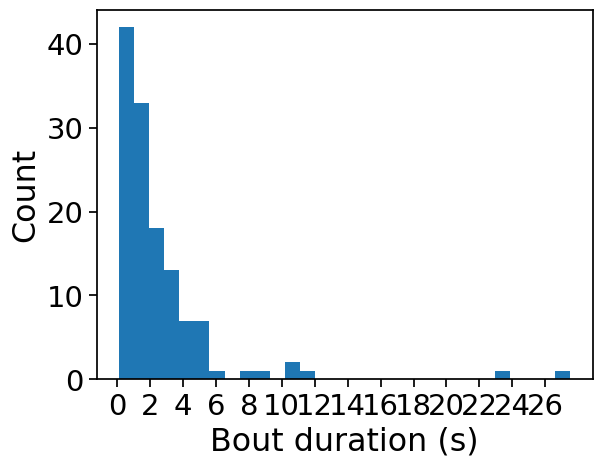

In [19]:
all_durations = []
for rec in sc.recordings:
    for ev, arr in rec.event_dict.items():
        if ev == "anogenital sniffing":  # or whichever
            all_durations.extend(arr[:,1] - arr[:,0])
plt.hist(np.array(all_durations)/1000, bins=30)
plt.xticks(np.arange(0, max(all_durations)/1000, 2))
plt.xlabel("Bout duration (s)")
plt.ylabel("Count")


In [20]:
import re

# Parameters for Wilcoxon test
event_length = 3      # seconds - standardized event window
baseline_window = 3   # seconds - baseline window before event
offset = 0            # no offset
exclude_offset = False

# Store all results
all_wilcoxon_results = []

for rec in sc.recordings:
    rec_name = rec.name
    
    # Extract subject and day
    subject_match = re.match(r'(\d+)_', rec_name)
    if not subject_match:
        continue
    subject_id = subject_match.group(1)
    
    if '_d0_' in rec_name or rec_name.endswith('_d0.rec') or '_d0_merged' in rec_name:
        day = 'd0'
    elif '_d7_' in rec_name or rec_name.endswith('_d7.rec') or '_d7_merged' in rec_name:
        day = 'd7'
    else:
        continue
    
    print(f"\n{rec_name} (Subject {subject_id}, {day.upper()})")
    
    # Get good units for this recording
    good_units = getattr(rec, "good_units", None)
    if good_units is None:
        if hasattr(rec, 'labels_dict'):
            good_units = [unit_id for unit_id, label in rec.labels_dict.items() if label == "good"]
        else:
            good_units = list(rec.unit_timestamps.keys())
    
    n_good_units = len([u for u in good_units if u in rec.unit_timestamps and len(rec.unit_timestamps[u]) > 0])
    
    # Process each cleaned event type
    if hasattr(rec, 'event_dict_cleaned') and rec.event_dict_cleaned:
        for event_name, event_windows_ms in rec.event_dict_cleaned.items():
            n_bouts = len(event_windows_ms)
            
            if n_bouts < 6:
                print(f"  {event_name:25s}: Skipped ({n_bouts} bouts < 6 minimum)")
                continue
            
            # Temporarily set event_dict to use cleaned events
            original_events = rec.event_dict.get(event_name, None)
            rec.event_dict[event_name] = event_windows_ms

            # Run Wilcoxon test using single_cell module
            wilcox_df = single_cell.wilcoxon_rec(
                rec,
                event_name,
                event_length,
                baseline_window,
                offset,
                exclude_offset
            )

            if wilcox_df is not None and not wilcox_df.empty:
                # ----------------------------------------------------------
                # Standardize "Unit" column
                # ----------------------------------------------------------
                # If the unit IDs are stored as the index, convert to a column
                if wilcox_df.index.name is not None and 'Unit' not in wilcox_df.columns:
                    wilcox_df = wilcox_df.reset_index().rename(columns={wilcox_df.index.name: 'Unit'})
                elif 'Unit' not in wilcox_df.columns:
                    # Try to detect any likely unit ID column name
                    possible_unit_cols = [c for c in wilcox_df.columns if 'unit' in c.lower() or 'cluster' in c.lower()]
                    if possible_unit_cols:
                        wilcox_df.rename(columns={possible_unit_cols[0]: 'Unit'}, inplace=True)
                    else:
                        # If no such column exists, assign numeric unit IDs
                        wilcox_df['Unit'] = np.arange(len(wilcox_df))
                
                # ----------------------------------------------------------
                # Count significance stats
                # ----------------------------------------------------------
                n_total = len(wilcox_df)
                n_sig = len(wilcox_df[wilcox_df['p value'] < 0.05])
                n_increase = len(wilcox_df[(wilcox_df['p value'] < 0.05) &
                                           (wilcox_df['event1 vs event2'] == 'increases')])
                n_decrease = len(wilcox_df[(wilcox_df['p value'] < 0.05) &
                                           (wilcox_df['event1 vs event2'] == 'decreases')])
                
                print(f"  {event_name:25s}: {n_total:3d} units, "
                      f"{n_sig:3d} sig ({100*n_sig/n_total:5.1f}%) [↑{n_increase}, ↓{n_decrease}]")
                
                # ----------------------------------------------------------
                # Store full results
                # ----------------------------------------------------------
                all_wilcoxon_results.append({
                    'recording': rec_name,
                    'subject': subject_id,
                    'day': day,
                    'event': event_name,
                    'n_bouts': n_bouts,
                    'n_units_total': n_total,
                    'n_sig': n_sig,
                    'n_increase': n_increase,
                    'n_decrease': n_decrease,
                    'pct_sig': 100 * n_sig / n_total if n_total > 0 else 0,
                    'wilcox_df': wilcox_df
                })
            
            # Restore original event_dict if it existed
            if original_events is not None:
                rec.event_dict[event_name] = original_events
                    
    else:
        print("  No cleaned events available")

print("\n" + "="*80)
print(f"WILCOXON TESTS COMPLETE: {len(all_wilcoxon_results)} event×recording combinations analyzed")
print("="*80)



32_rehouse_d7_merged.rec (Subject 32, D7)
  sniffing object          :   3 units,   0 sig (  0.0%) [↑0, ↓0]
  anogenital sniffing      :   3 units,   1 sig ( 33.3%) [↑1, ↓0]
  facial sniffing          :   3 units,   0 sig (  0.0%) [↑0, ↓0]

22_rehouse_d7_merged.rec (Subject 22, D7)
  fighting                 : Skipped (1 bouts < 6 minimum)
  anogenital sniffing      :   9 units,   1 sig ( 11.1%) [↑0, ↓1]
  facial sniffing          :   9 units,   2 sig ( 22.2%) [↑2, ↓0]
  sniffing object          :   9 units,   1 sig ( 11.1%) [↑0, ↓1]

44_rehouse_d7_merged.rec (Subject 44, D7)
  sniffing object          :   7 units,   0 sig (  0.0%) [↑0, ↓0]
  anogenital sniffing      :   7 units,   0 sig (  0.0%) [↑0, ↓0]
  facial sniffing          :   7 units,   0 sig (  0.0%) [↑0, ↓0]

41_rehouse_d7_merged.rec (Subject 41, D7)
  chasing                  : Skipped (2 bouts < 6 minimum)
  anogenital sniffing      :  28 units,   2 sig (  7.1%) [↑2, ↓0]
  facial sniffing          :  28 units,   2 sig ( 

/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10/site-packages/scipy/_lib/_util.py:1023: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)


  facial sniffing          :  24 units,   5 sig ( 20.8%) [↑5, ↓0]
  anogenital sniffing      :  24 units,   2 sig (  8.3%) [↑2, ↓0]

WILCOXON TESTS COMPLETE: 21 event×recording combinations analyzed


In [21]:
wil_df = pd.DataFrame(all_wilcoxon_results)
wil_df.head()

,recording,subject,day,event,n_bouts,n_units_total,n_sig,n_increase,n_decrease,pct_sig,wilcox_df
0,32_rehouse_d7_merged.rec,32,d7,sniffing object,25,3,0,0,0,0.000000,Wilcoxon Stat p value event1 vs event2 Unit 13 122.5 0.896655 not significant 0 18 68.5 0.286040 not significant 1 22 125.5 0.700809 not significant 2
1,32_rehouse_d7_merged.rec,32,d7,anogenital sniffing,19,3,1,1,0,33.333333,Wilcoxon Stat p value event1 vs event2 Unit 13 31.5 0.033105 increases 0 18 35.5 0.163561 not significant 1 22 41.5 0.170527 not significant 2
2,32_rehouse_d7_merged.rec,32,d7,facial sniffing,13,3,0,0,0,0.000000,Wilcoxon Stat p value event1 vs event2 Unit 13 34.0 0.725098 not significant 0 18 16.5 0.867188 not significant 1 22 23.0 0.225586 not significant 2
3,22_rehouse_d7_merged.rec,22,d7,anogenital sniffing,10,9,1,0,1,11.111111,Wilcoxon Stat p value event1 vs event2 Unit 63 25.0 0.845703 not significant 0 65 15.0 0.710938 not significant 1 25 11.0 0.671875 not significant 2 60 22.0 0.625000 not significant 3 119 10.0 0.156250 not significant 4 116 12.0 0.130859 not significant 5 129 6.0 0.203125 not significant 6 114 19.0 0.718750 not significant 7 103 0.0 0.003906 decreases 8
4,22_rehouse_d7_merged.rec,22,d7,facial sniffing,12,9,2,2,0,22.222222,Wilcoxon Stat p value event1 vs event2 Unit 63 20.0 0.476562 not significant 0 65 33.5 0.692383 not significant 1 25 21.5 0.960938 not significant 2 60 23.5 0.712891 not significant 3 119 6.0 0.012695 increases 4 116 12.5 0.070312 not significant 5 129 28.5 0.714844 not significant 6 114 12.5 0.136719 not significant 7 103 11.0 0.049805 increases 8


In [22]:
inc_wilcox = sum(wil_df["n_increase"])
inc_wilcox

28

In [23]:
dec_wilcox = sum(wil_df["n_decrease"])
dec_wilcox

2

In [24]:
sig_wilcox = sum(wil_df['n_sig'])
sig_wilcox

30

SOCIAL BEHAVIORS
Saved: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots/significant_units_by_social_behavior_barplot.png


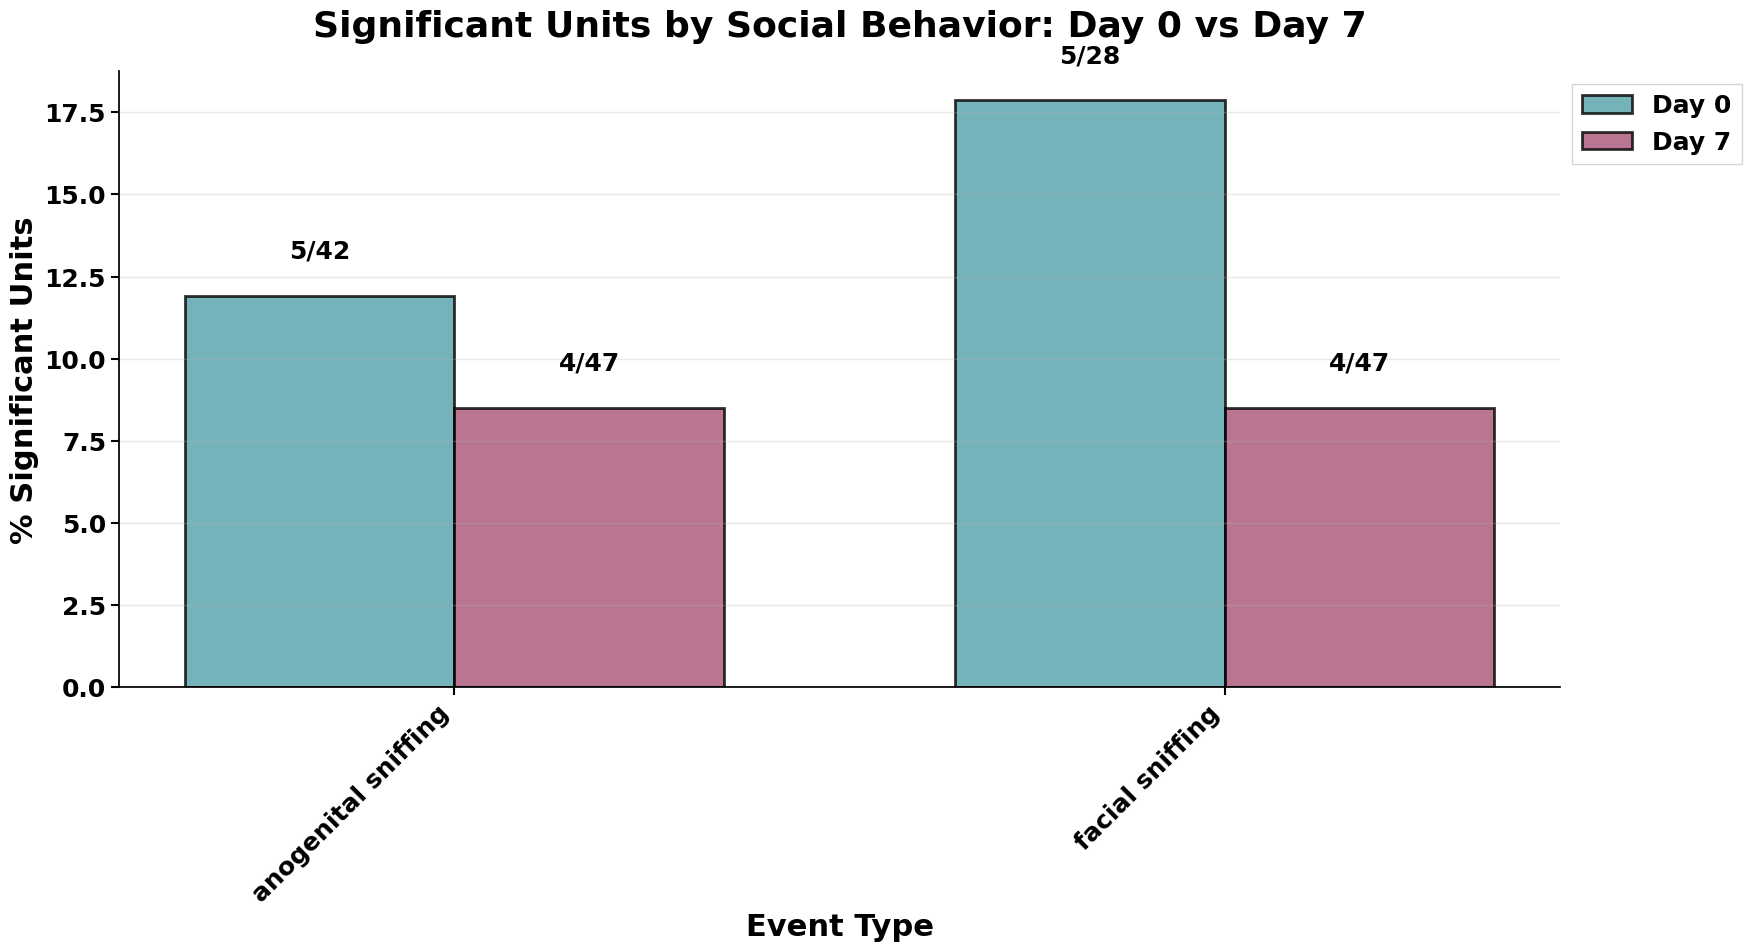


OBJECT BEHAVIOR
Saved: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots/significant_units_for_object_sniffing_barplot.png


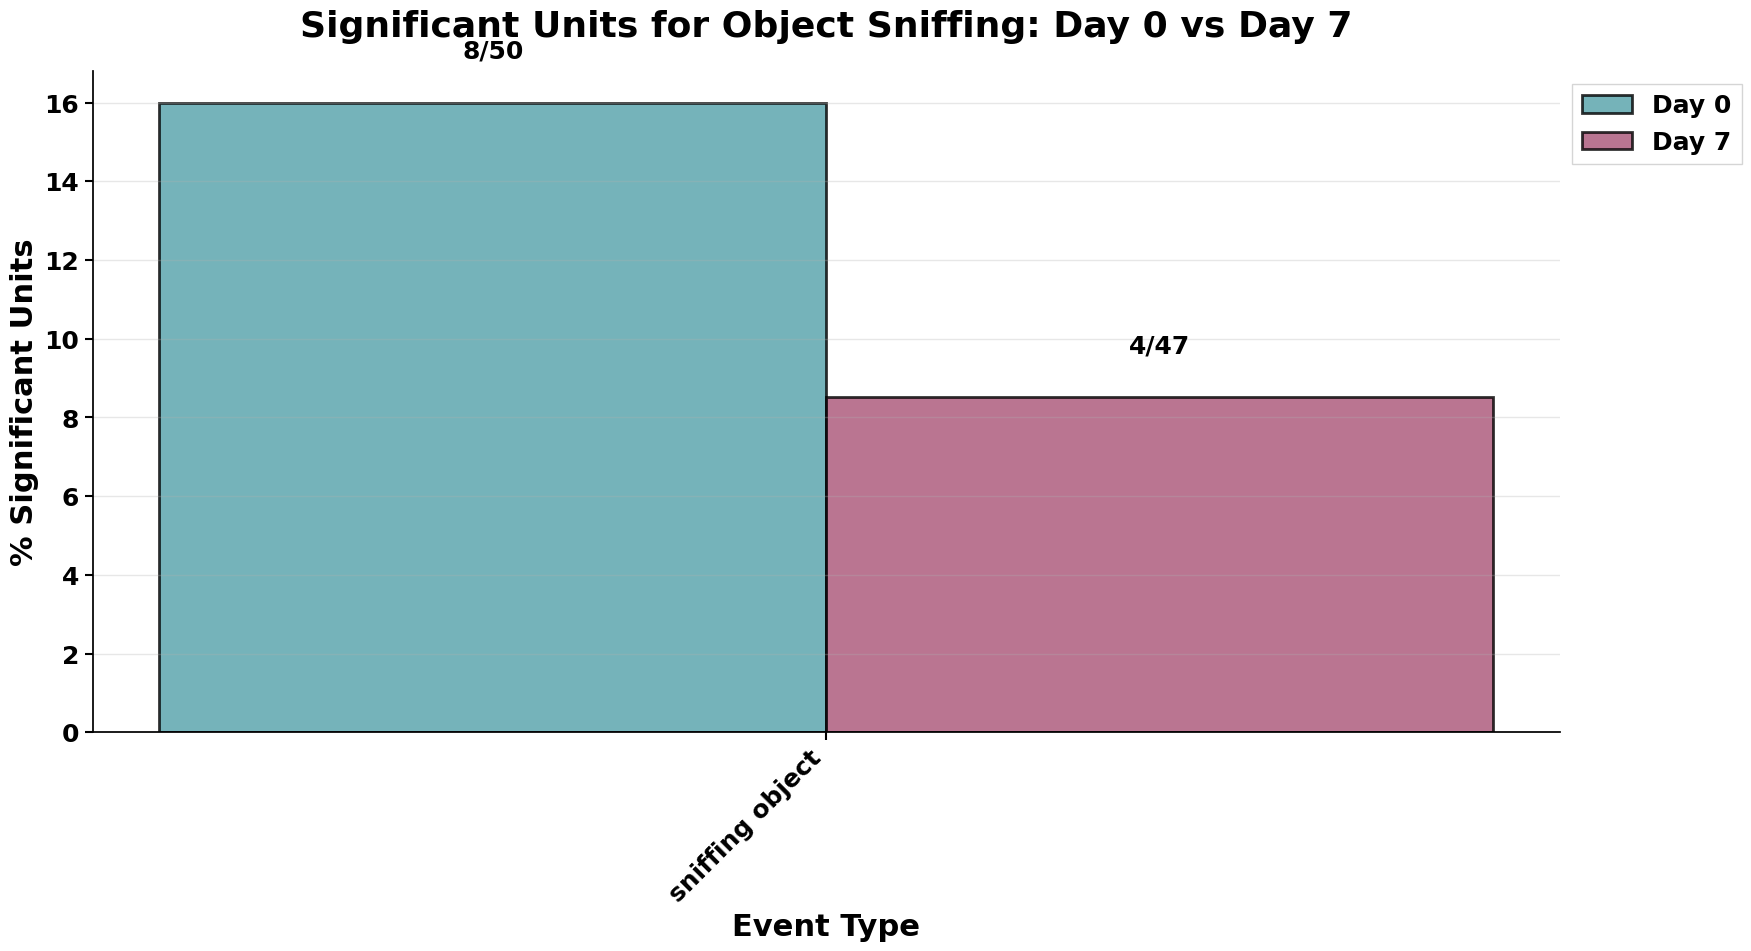


DETAILED SUMMARY: UNITS TESTED AND SIGNIFICANT UNITS BY EVENT TYPE AND DAY
Event                               Day   Total Units     Sig Units       % Sig     
----------------------------------------------------------------------------------------------------
anogenital sniffing                 d0    42              5                 11.9%
anogenital sniffing                 d7    47              4                  8.5%

facial sniffing                     d0    28              5                 17.9%
facial sniffing                     d7    47              4                  8.5%

sniffing object                     d0    50              8                 16.0%
sniffing object                     d7    47              4                  8.5%



In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# SAVE DIRECTORY (your target)
# -----------------------------
save_dir = "/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots"

os.makedirs(save_dir, exist_ok=True)   # Auto-create directory if missing

# Convert results to DataFrame
wilcoxon_df = pd.DataFrame(all_wilcoxon_results)

# Define colors for Day 0 and Day 7
COLOR_DAY0 = '#53A1A9'  # Teal
COLOR_DAY7 = '#A95376'  # Magenta

# ============================================================================
# STAT CALCULATIONS
# ============================================================================

# Calculate statistics for d0
sig_by_event_d0 = wilcoxon_df[wilcoxon_df['day'] == 'd0'].groupby('event')['n_sig'].sum()
total_by_event_d0 = wilcoxon_df[wilcoxon_df['day'] == 'd0'].groupby('event')['n_units_total'].sum()

# Calculate statistics for d7
sig_by_event_d7 = wilcoxon_df[wilcoxon_df['day'] == 'd7'].groupby('event')['n_sig'].sum()
total_by_event_d7 = wilcoxon_df[wilcoxon_df['day'] == 'd7'].groupby('event')['n_units_total'].sum()

# Get all unique events
all_events = sorted(set(total_by_event_d0.index) | set(total_by_event_d7.index))

# Separate social from object sniffing
social_events = [e for e in all_events if e != 'sniffing object']
object_events = [e for e in all_events if e == 'sniffing object']


# ============================================================================
# FUNCTION TO CREATE + SAVE PLOTS
# ============================================================================

def create_event_plot(events_to_plot, title_suffix):
    if not events_to_plot:
        return
    
    # Prepare data
    d0_sig_counts = [sig_by_event_d0.get(event, 0) for event in events_to_plot]
    d0_total_counts = [total_by_event_d0.get(event, 0) for event in events_to_plot]
    d7_sig_counts = [sig_by_event_d7.get(event, 0) for event in events_to_plot]
    d7_total_counts = [total_by_event_d7.get(event, 0) for event in events_to_plot]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(18, 10))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events_to_plot))

    width = 0.12 if len(events_to_plot) == 1 else 0.35
    
    d0_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d0_sig_counts, d0_total_counts)]
    d7_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d7_sig_counts, d7_total_counts)]
    
    bars1 = ax.bar(x - width/2, d0_percent, width, label='Day 0',
                   alpha=0.8, edgecolor='black', linewidth=2, color=COLOR_DAY0)
    bars2 = ax.bar(x + width/2, d7_percent, width, label='Day 7',
                   alpha=0.8, edgecolor='black', linewidth=2, color=COLOR_DAY7)
    
    ax.set_ylabel('% Significant Units', fontsize=22, fontweight='bold')
    ax.set_xlabel('Event Type', fontsize=22, fontweight='bold')
    ax.set_title(f'{title_suffix}: Day 0 vs Day 7', fontsize=26, fontweight='bold', pad=25)

    clean_event_labels = [event.replace('(', '').replace(')', '') for event in events_to_plot]
    
    ax.set_xticks(x)
    ax.set_xticklabels(clean_event_labels, rotation=45, ha='right', fontsize=18, fontweight='bold')

    ax.tick_params(axis='y', labelsize=18, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6)
    
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    
    legend = ax.legend(fontsize=18, frameon=True, fancybox=False,
                       loc='upper left', bbox_to_anchor=(1.0, 1.0))

    for text in legend.get_texts():
        text.set_fontweight('bold')
    
    sns.despine(ax=ax)
    ax.grid(axis='y', alpha=0.3, linewidth=1)
    
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        if d0_total_counts[i] > 0:
            height1 = bar1.get_height()
            ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 1,
                    f'{d0_sig_counts[i]}/{d0_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')
        
        if d7_total_counts[i] > 0:
            height2 = bar2.get_height()
            ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 1,
                    f'{d7_sig_counts[i]}/{d7_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

    plt.tight_layout()

    # -----------------------
    # SAVE THE PLOT
    # -----------------------
    clean_title = title_suffix.lower().replace(" ", "_").replace(":", "")
    save_path = os.path.join(save_dir, f"{clean_title}_barplot.png")
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    
    plt.show()


# ============================================================================
# RUN + SAVE PLOTS
# ============================================================================

print("="*100)
print("SOCIAL BEHAVIORS")
print("="*100)
create_event_plot(social_events, 'Significant Units by Social Behavior')

print("\n" + "="*100)
print("OBJECT BEHAVIOR")
print("="*100)
create_event_plot(object_events, 'Significant Units for Object Sniffing')

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*100)
print("DETAILED SUMMARY: UNITS TESTED AND SIGNIFICANT UNITS BY EVENT TYPE AND DAY")
print("="*100)
print(f"{'Event':<35} {'Day':<5} {'Total Units':<15} {'Sig Units':<15} {'% Sig':<10}")
print("-"*100)

for event in all_events:
    d0_total = total_by_event_d0.get(event, 0)
    d0_sig = sig_by_event_d0.get(event, 0)
    d0_pct = (d0_sig / d0_total * 100) if d0_total > 0 else 0
    print(f"{event:<35} {'d0':<5} {d0_total:<15} {d0_sig:<15} {d0_pct:>6.1f}%")
    
    d7_total = total_by_event_d7.get(event, 0)
    d7_sig = sig_by_event_d7.get(event, 0)
    d7_pct = (d7_sig / d7_total * 100) if d7_total > 0 else 0
    print(f"{event:<35} {'d7':<5} {d7_total:<15} {d7_sig:<15} {d7_pct:>6.1f}%")
    print()

print("="*100)


## Pie Plots, Percentages of Sniffing types for day 0 and day 7

Saved pie plot to:
/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots/pieplot_significant_units_d0_vs_d7.png



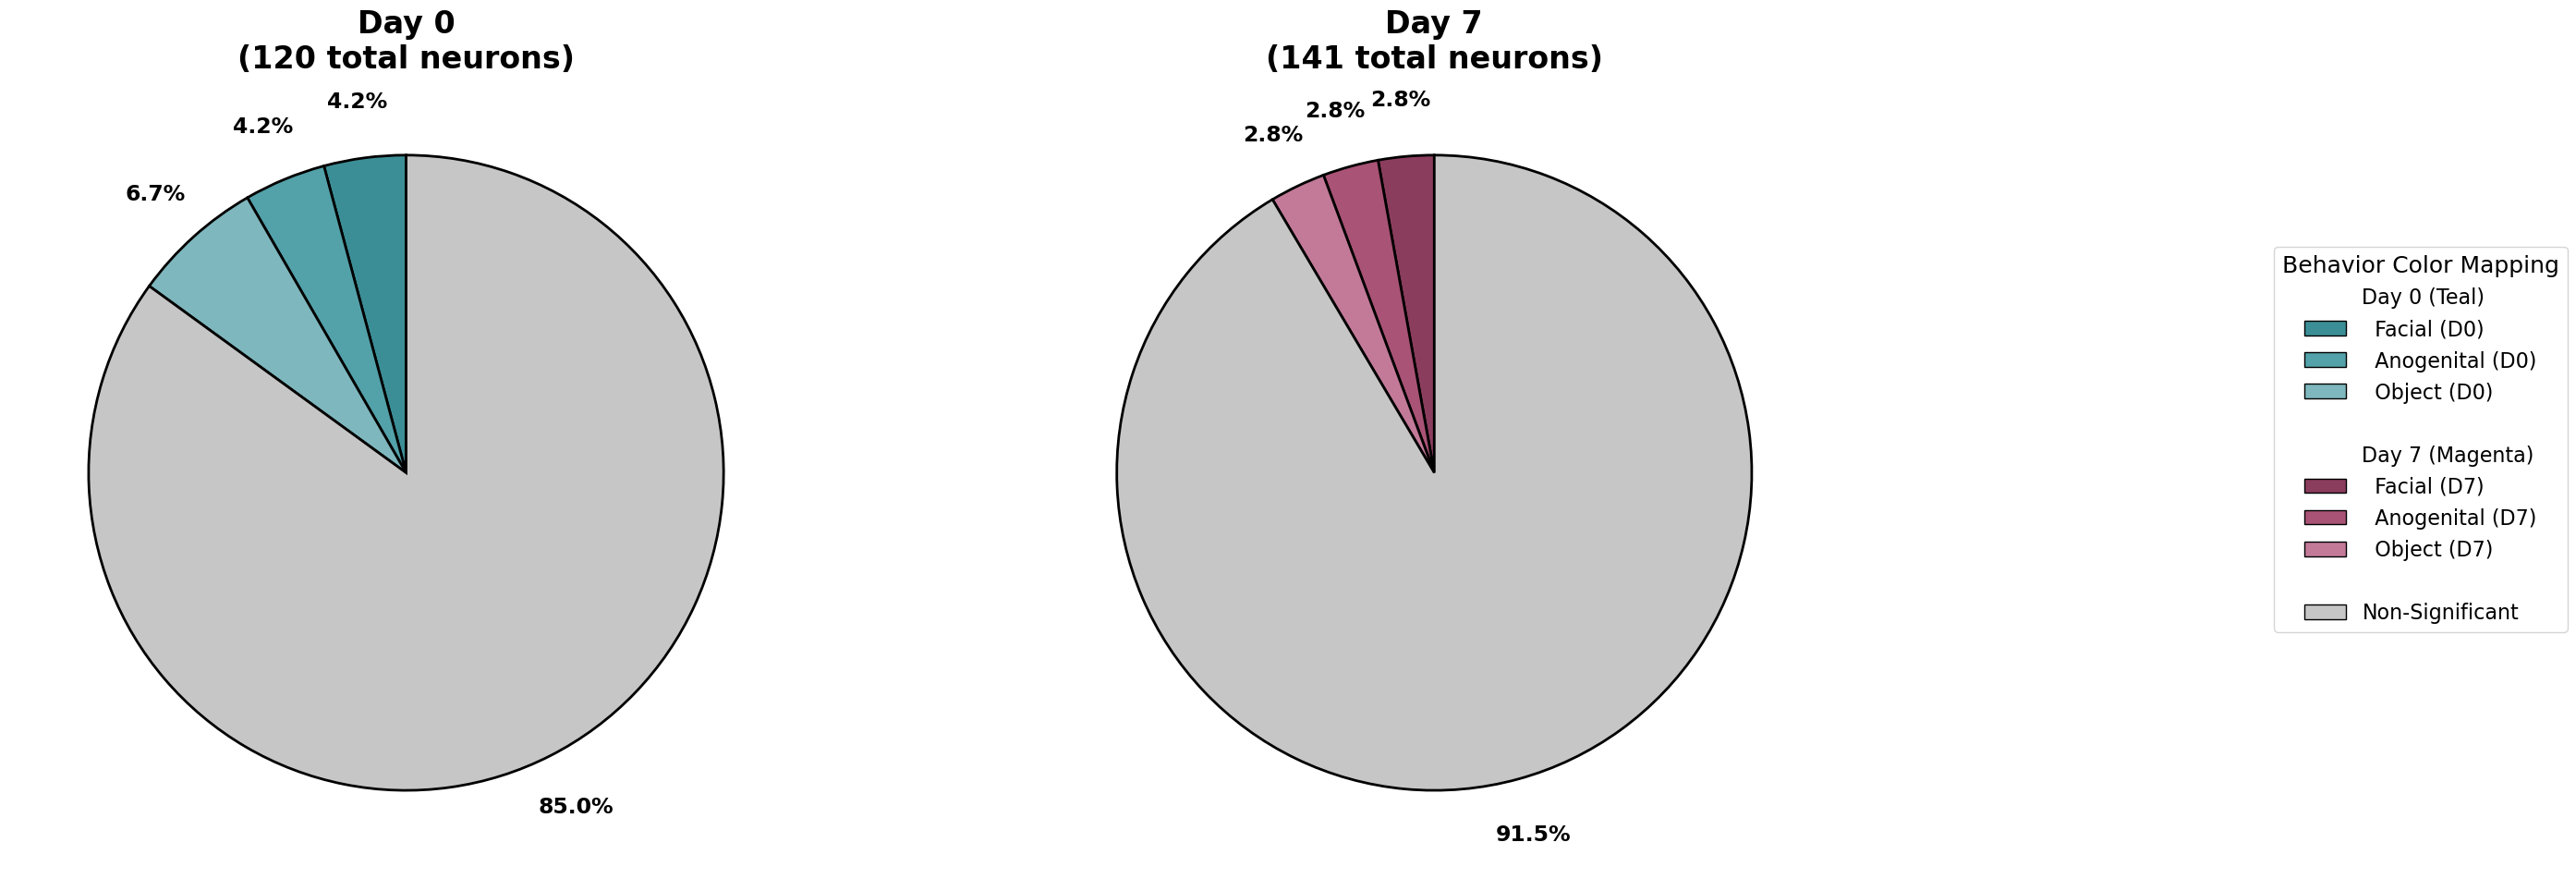

In [42]:
# ============================================================================
# PIE PLOTS: % Significant Units (Day 0 vs Day 7) — WITH SAVE FUNCTION
# ============================================================================

import os

# -----------------------
# SAVE DIRECTORY
# -----------------------
save_dir = "/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots"
os.makedirs(save_dir, exist_ok=True)


def make_pie_plots(sig_by_event_d0, total_by_event_d0,
                   sig_by_event_d7, total_by_event_d7):
    
    sniffing_behaviors = ['facial sniffing', 'anogenital sniffing', 'sniffing object']

    # ----- Compute D0 percentages -----
    d0_total = sum(total_by_event_d0.get(b, 0) for b in sniffing_behaviors)
    d0_sizes = [
        (sig_by_event_d0.get(b, 0) / d0_total * 100) if d0_total > 0 else 0
        for b in sniffing_behaviors
    ]
    d0_sizes.append(100 - sum(d0_sizes))

    # ----- Compute D7 percentages -----
    d7_total = sum(total_by_event_d7.get(b, 0) for b in sniffing_behaviors)
    d7_sizes = [
        (sig_by_event_d7.get(b, 0) / d7_total * 100) if d7_total > 0 else 0
        for b in sniffing_behaviors
    ]
    d7_sizes.append(100 - sum(d7_sizes))

    # ----- Slice colors -----
    d0_colors = ['#3C8E96', '#53A1A9', '#7EB7BD', '#C6C6C6']   # teal tones
    d7_colors = ['#8B3D5E', '#A95376', '#C37A99', '#C6C6C6']   # magenta tones

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 10))
    fig.patch.set_alpha(0.0)

    # ====================================================
    # Pie helper with outside labels
    # ====================================================
    def plot_outside(ax, sizes, colors, title, total_neurons):
        wedges, _ = ax.pie(
            sizes,
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2}
        )

        for w in wedges:
            mid = (w.theta1 + w.theta2) / 2
            x, y = np.cos(np.deg2rad(mid)), np.sin(np.deg2rad(mid))
            pct = (w.theta2 - w.theta1) / 360 * 100

            ax.text(
                x * 1.18, y * 1.18,
                f"{pct:.1f}%",
                fontsize=17, fontweight='bold',
                ha='center', va='center',
                color='black'
            )

        ax.set_title(title, fontsize=24, fontweight='bold')
        ax.set_aspect('equal')

    # ----- Day 0 -----
    plot_outside(
        ax1, d0_sizes, d0_colors,
        f"Day 0\n({d0_total} total neurons)", d0_total
    )

    # ----- Day 7 -----
    plot_outside(
        ax2, d7_sizes, d7_colors,
        f"Day 7\n({d7_total} total neurons)", d7_total
    )

    # ====================================================
    # GROUPED LEGEND (Day 0 block, Day 7 block, Non-Sig block)
    # ====================================================

    from matplotlib.patches import Patch

    legend_handles = [
        # --- HEADER: DAY 0 ---
        Patch(facecolor='none', edgecolor='none', label="Day 0 (Teal)", linewidth=0),
        Patch(facecolor=d0_colors[0], edgecolor='black', label="  Facial (D0)"),
        Patch(facecolor=d0_colors[1], edgecolor='black', label="  Anogenital (D0)"),
        Patch(facecolor=d0_colors[2], edgecolor='black', label="  Object (D0)"),

        Patch(facecolor='none', edgecolor='none', label=""),  # spacer

        # --- HEADER: DAY 7 ---
        Patch(facecolor='none', edgecolor='none', label="Day 7 (Magenta)", linewidth=0),
        Patch(facecolor=d7_colors[0], edgecolor='black', label="  Facial (D7)"),
        Patch(facecolor=d7_colors[1], edgecolor='black', label="  Anogenital (D7)"),
        Patch(facecolor=d7_colors[2], edgecolor='black', label="  Object (D7)"),

        Patch(facecolor='none', edgecolor='none', label=""),  # spacer

        # --- NON-SIGNIFICANT ---
        Patch(facecolor='#C6C6C6', edgecolor='black', label="Non-Significant")
    ]

    fig.legend(
        handles=legend_handles,
        loc='center right',
        bbox_to_anchor=(1.28, 0.5),
        fontsize=16,
        title="Behavior Color Mapping",
        title_fontsize=18,
    )

    plt.tight_layout()

    # -----------------------
    # SAVE THE FIGURE
    # -----------------------
    save_path = os.path.join(save_dir, "pieplot_significant_units_d0_vs_d7.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved pie plot to:\n{save_path}\n")

    plt.show()


# CALL IT
make_pie_plots(
    sig_by_event_d0,
    total_by_event_d0,
    sig_by_event_d7,
    total_by_event_d7
)



Saved FIXED complete-recordings pie plot to:
/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots/complete_recordings_pieplot_d0_vs_d7_FIXED.png



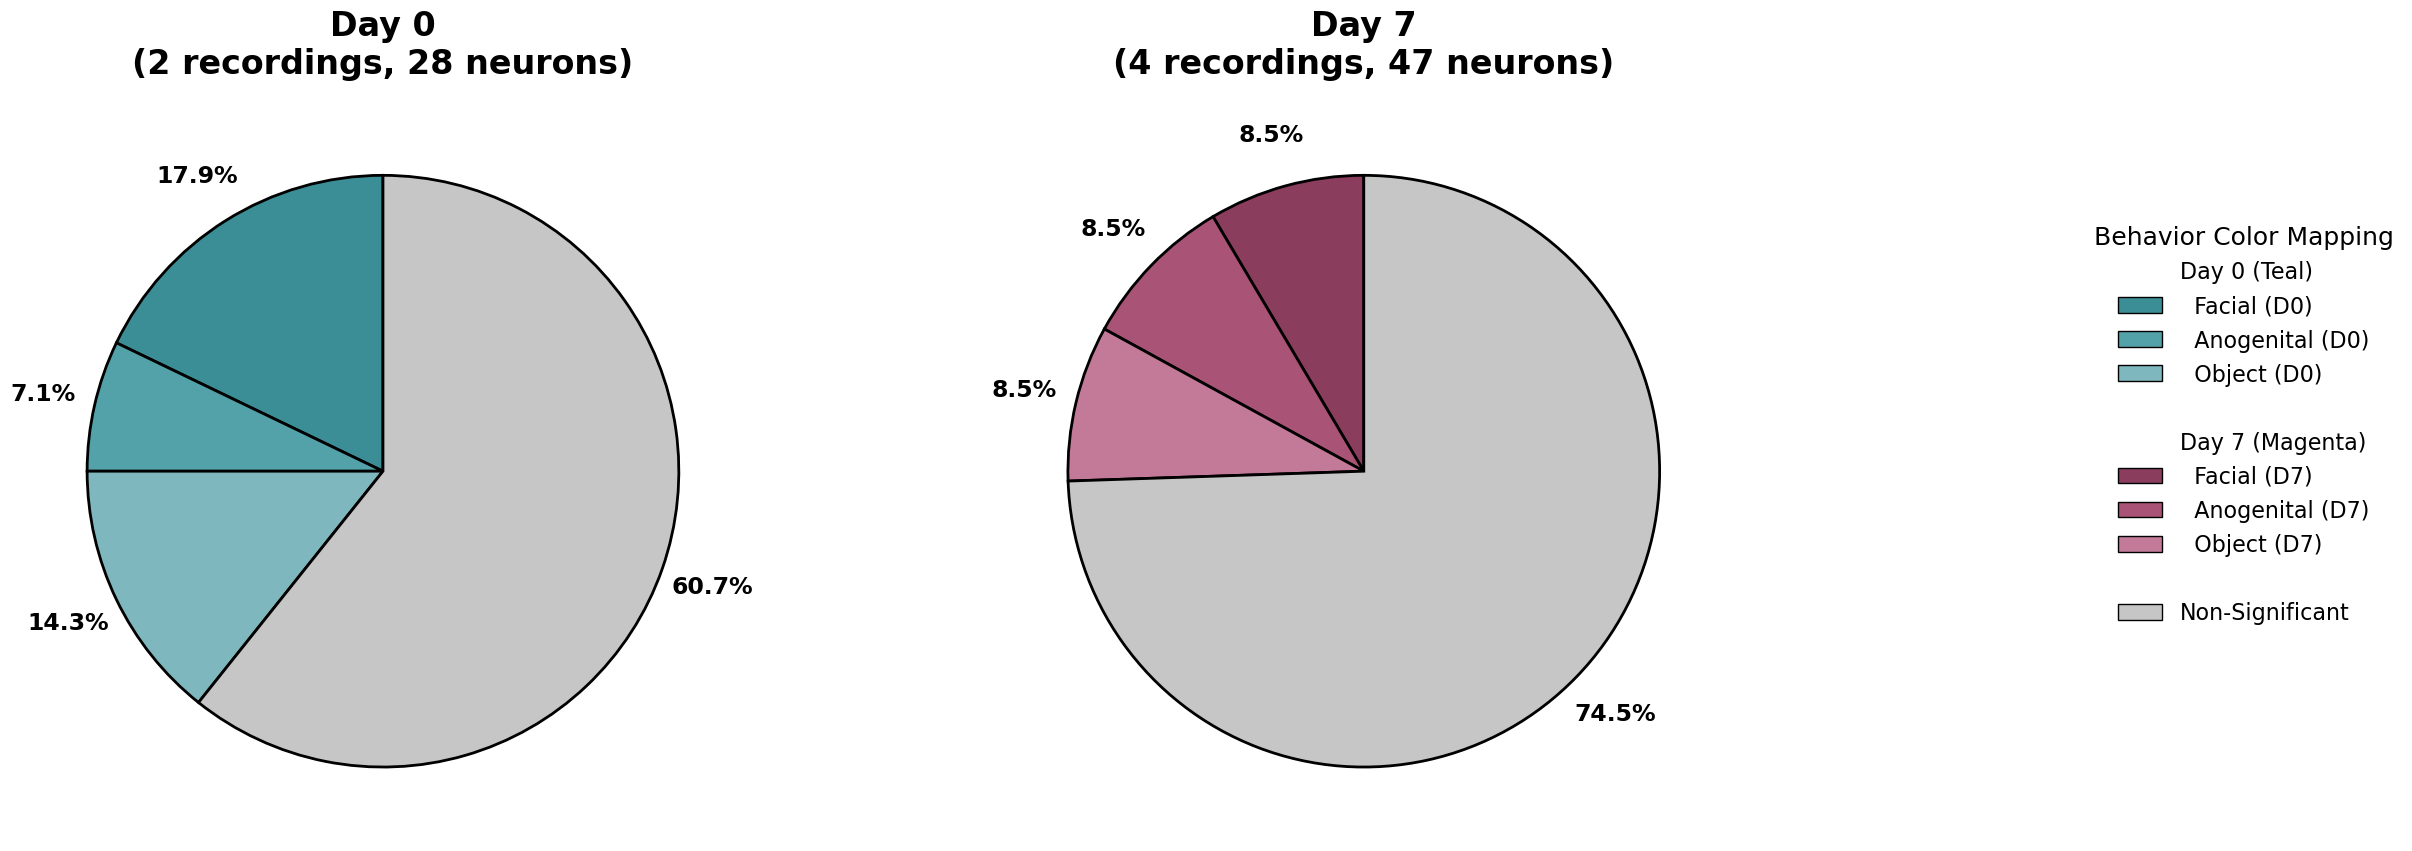

In [44]:
# ============================================================================
# FIXED PIE PLOTS — ONLY USING RECORDINGS WHERE ALL 3 SNIFFING BEHAVIORS EXIST
# ✔ Correct neuron counting (no double-counting)
# ✔ Outside labels
# ✔ Grouped legend
# ✔ Saves figure automatically
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------
# SAVE DIRECTORY
# -----------------------
save_dir = "/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/plots"
os.makedirs(save_dir, exist_ok=True)

sniffing_behaviors = ["facial sniffing", "anogenital sniffing", "sniffing object"]

# ---------------------------------------------------------------------------
# 1. Identify recordings that contain ALL 3 sniffing behaviors
# ---------------------------------------------------------------------------
def get_complete_recordings(day):
    day_df = wilcoxon_df[(wilcoxon_df["day"] == day) & 
                         (wilcoxon_df["event"].isin(sniffing_behaviors))]

    valid_subjects = []

    for subject in day_df["subject"].unique():
        subject_df = day_df[day_df["subject"] == subject]
        present = set(subject_df["event"].unique())
        if present == set(sniffing_behaviors):
            valid_subjects.append(subject)

    return wilcoxon_df[(wilcoxon_df["day"] == day) &
                       (wilcoxon_df["subject"].isin(valid_subjects)) &
                       (wilcoxon_df["event"].isin(sniffing_behaviors))]


d0_df = get_complete_recordings("d0")
d7_df = get_complete_recordings("d7")


# ---------------------------------------------------------------------------
# 2. Compute overall significant + total neurons WITHOUT double counting
# ---------------------------------------------------------------------------
def compute_counts(df):
    if df.empty:
        return None, 0, []

    subjects = sorted(df["subject"].unique())

    # ✔ FIX: count each recording’s neurons only once
    neurons_per_recording = (
        df[["recording", "n_units_total"]]
        .drop_duplicates()
        .groupby("recording")
        .first()["n_units_total"]
    )
    total_good = neurons_per_recording.sum()

    # Significant counts per behavior (this part was already correct)
    sig_counts = {
        b: df[df["event"] == b]["n_sig"].sum()
        for b in sniffing_behaviors
    }

    return sig_counts, total_good, subjects


d0_sig_counts, d0_total_good, d0_subjects = compute_counts(d0_df)
d7_sig_counts, d7_total_good, d7_subjects = compute_counts(d7_df)


# ---------------------------------------------------------------------------
# 3. PIE PLOT HELPER — outside percentage labels + tones
# ---------------------------------------------------------------------------
def plot_pie(ax, sig_counts, total_good, subjects, day_title, color_tones):
    if sig_counts is None or total_good == 0:
        ax.text(0, 0, "No complete\nrecordings",
                ha="center", va="center", fontsize=18, fontweight="bold")
        ax.set_title(f"{day_title}\n(No complete recordings)",
                     fontsize=24, fontweight="bold", pad=20)
        ax.set_facecolor("none")
        return

    # Calculate percentages per behavior
    percentages = [(sig_counts[b] / total_good) * 100 for b in sniffing_behaviors]
    nonsig_pct = 100 - sum(percentages)

    sizes = percentages + [nonsig_pct]
    colors = color_tones + ["#C6C6C6"]

    wedges = ax.pie(
        sizes,
        startangle=90,
        colors=colors,
        wedgeprops={"edgecolor": "black", "linewidth": 2}
    )[0]

    # ---- Outside percentage labels ----
    for w in wedges:
        mid = (w.theta1 + w.theta2) / 2
        x = np.cos(np.deg2rad(mid))
        y = np.sin(np.deg2rad(mid))
        pct = (w.theta2 - w.theta1) / 360 * 100

        ax.text(
            x * 1.18, y * 1.18,
            f"{pct:.1f}%",
            ha="center", va="center",
            fontsize=17, fontweight="bold",
            color="black"
        )

    ax.set_title(
        f"{day_title}\n({len(subjects)} recordings, {total_good} neurons)",
        fontsize=24, fontweight="bold", pad=20
    )
    ax.set_aspect("equal")
    ax.set_facecolor("none")


# ---------------------------------------------------------------------------
# 4. MAKE FIGURE
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_alpha(0.0)

# Teal = D0, Magenta = D7
day0_colors = ["#3C8E96", "#53A1A9", "#7EB7BD"]
day7_colors = ["#8B3D5E", "#A95376", "#C37A99"]

plot_pie(ax1, d0_sig_counts, d0_total_good, d0_subjects, "Day 0", day0_colors)
plot_pie(ax2, d7_sig_counts, d7_total_good, d7_subjects, "Day 7", day7_colors)


# ---------------------------------------------------------------------------
# 5. GROUPED LEGEND
# ---------------------------------------------------------------------------
legend_handles = [
    # ---- DAY 0 HEADER ----
    Patch(facecolor='none', edgecolor='none', label="Day 0 (Teal)"),
    Patch(facecolor=day0_colors[0], edgecolor='black', label="  Facial (D0)"),
    Patch(facecolor=day0_colors[1], edgecolor='black', label="  Anogenital (D0)"),
    Patch(facecolor=day0_colors[2], edgecolor='black', label="  Object (D0)"),
    Patch(facecolor='none', edgecolor='none', label=""),

    # ---- DAY 7 HEADER ----
    Patch(facecolor='none', edgecolor='none', label="Day 7 (Magenta)"),
    Patch(facecolor=day7_colors[0], edgecolor='black', label="  Facial (D7)"),
    Patch(facecolor=day7_colors[1], edgecolor='black', label="  Anogenital (D7)"),
    Patch(facecolor=day7_colors[2], edgecolor='black', label="  Object (D7)"),
    Patch(facecolor='none', edgecolor='none', label=""),

    # ---- NON-SIGNIFICANT ----
    Patch(facecolor="#C6C6C6", edgecolor='black', label="Non-Significant")
]

fig.legend(
    handles=legend_handles,
    loc='center right',
    bbox_to_anchor=(1.27, 0.5),
    fontsize=16,
    title="Behavior Color Mapping",
    title_fontsize=18,
    frameon=False
)

plt.tight_layout()


# ---------------------------------------------------------------------------
# 6. SAVE FIGURE
# ---------------------------------------------------------------------------
save_path = os.path.join(save_dir, "complete_recordings_pieplot_d0_vs_d7_FIXED.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"\nSaved FIXED complete-recordings pie plot to:\n{save_path}\n")

plt.show()


In [54]:
!jupyter nbconvert --to script /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/wilcoxin_unitfiringrates.ipynb

[NbConvertApp] Converting notebook /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/wilcoxin_unitfiringrates.ipynb to script
[NbConvertApp] Writing 42593 bytes to /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/wilcoxin_unitfiringrates.py


In [26]:
import spike.spike_analysis.normalization as norm

In [39]:
importlib.reload(spike_collection)
importlib.reload(single_cell)
importlib.reload(norm)

<module 'spike.spike_analysis.normalization' from '/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/spike/spike_analysis/normalization.py'>

Wilcoxon can't be done on 32_rehouse_d0_merged.rec anogenital sniffing, because <6 samples


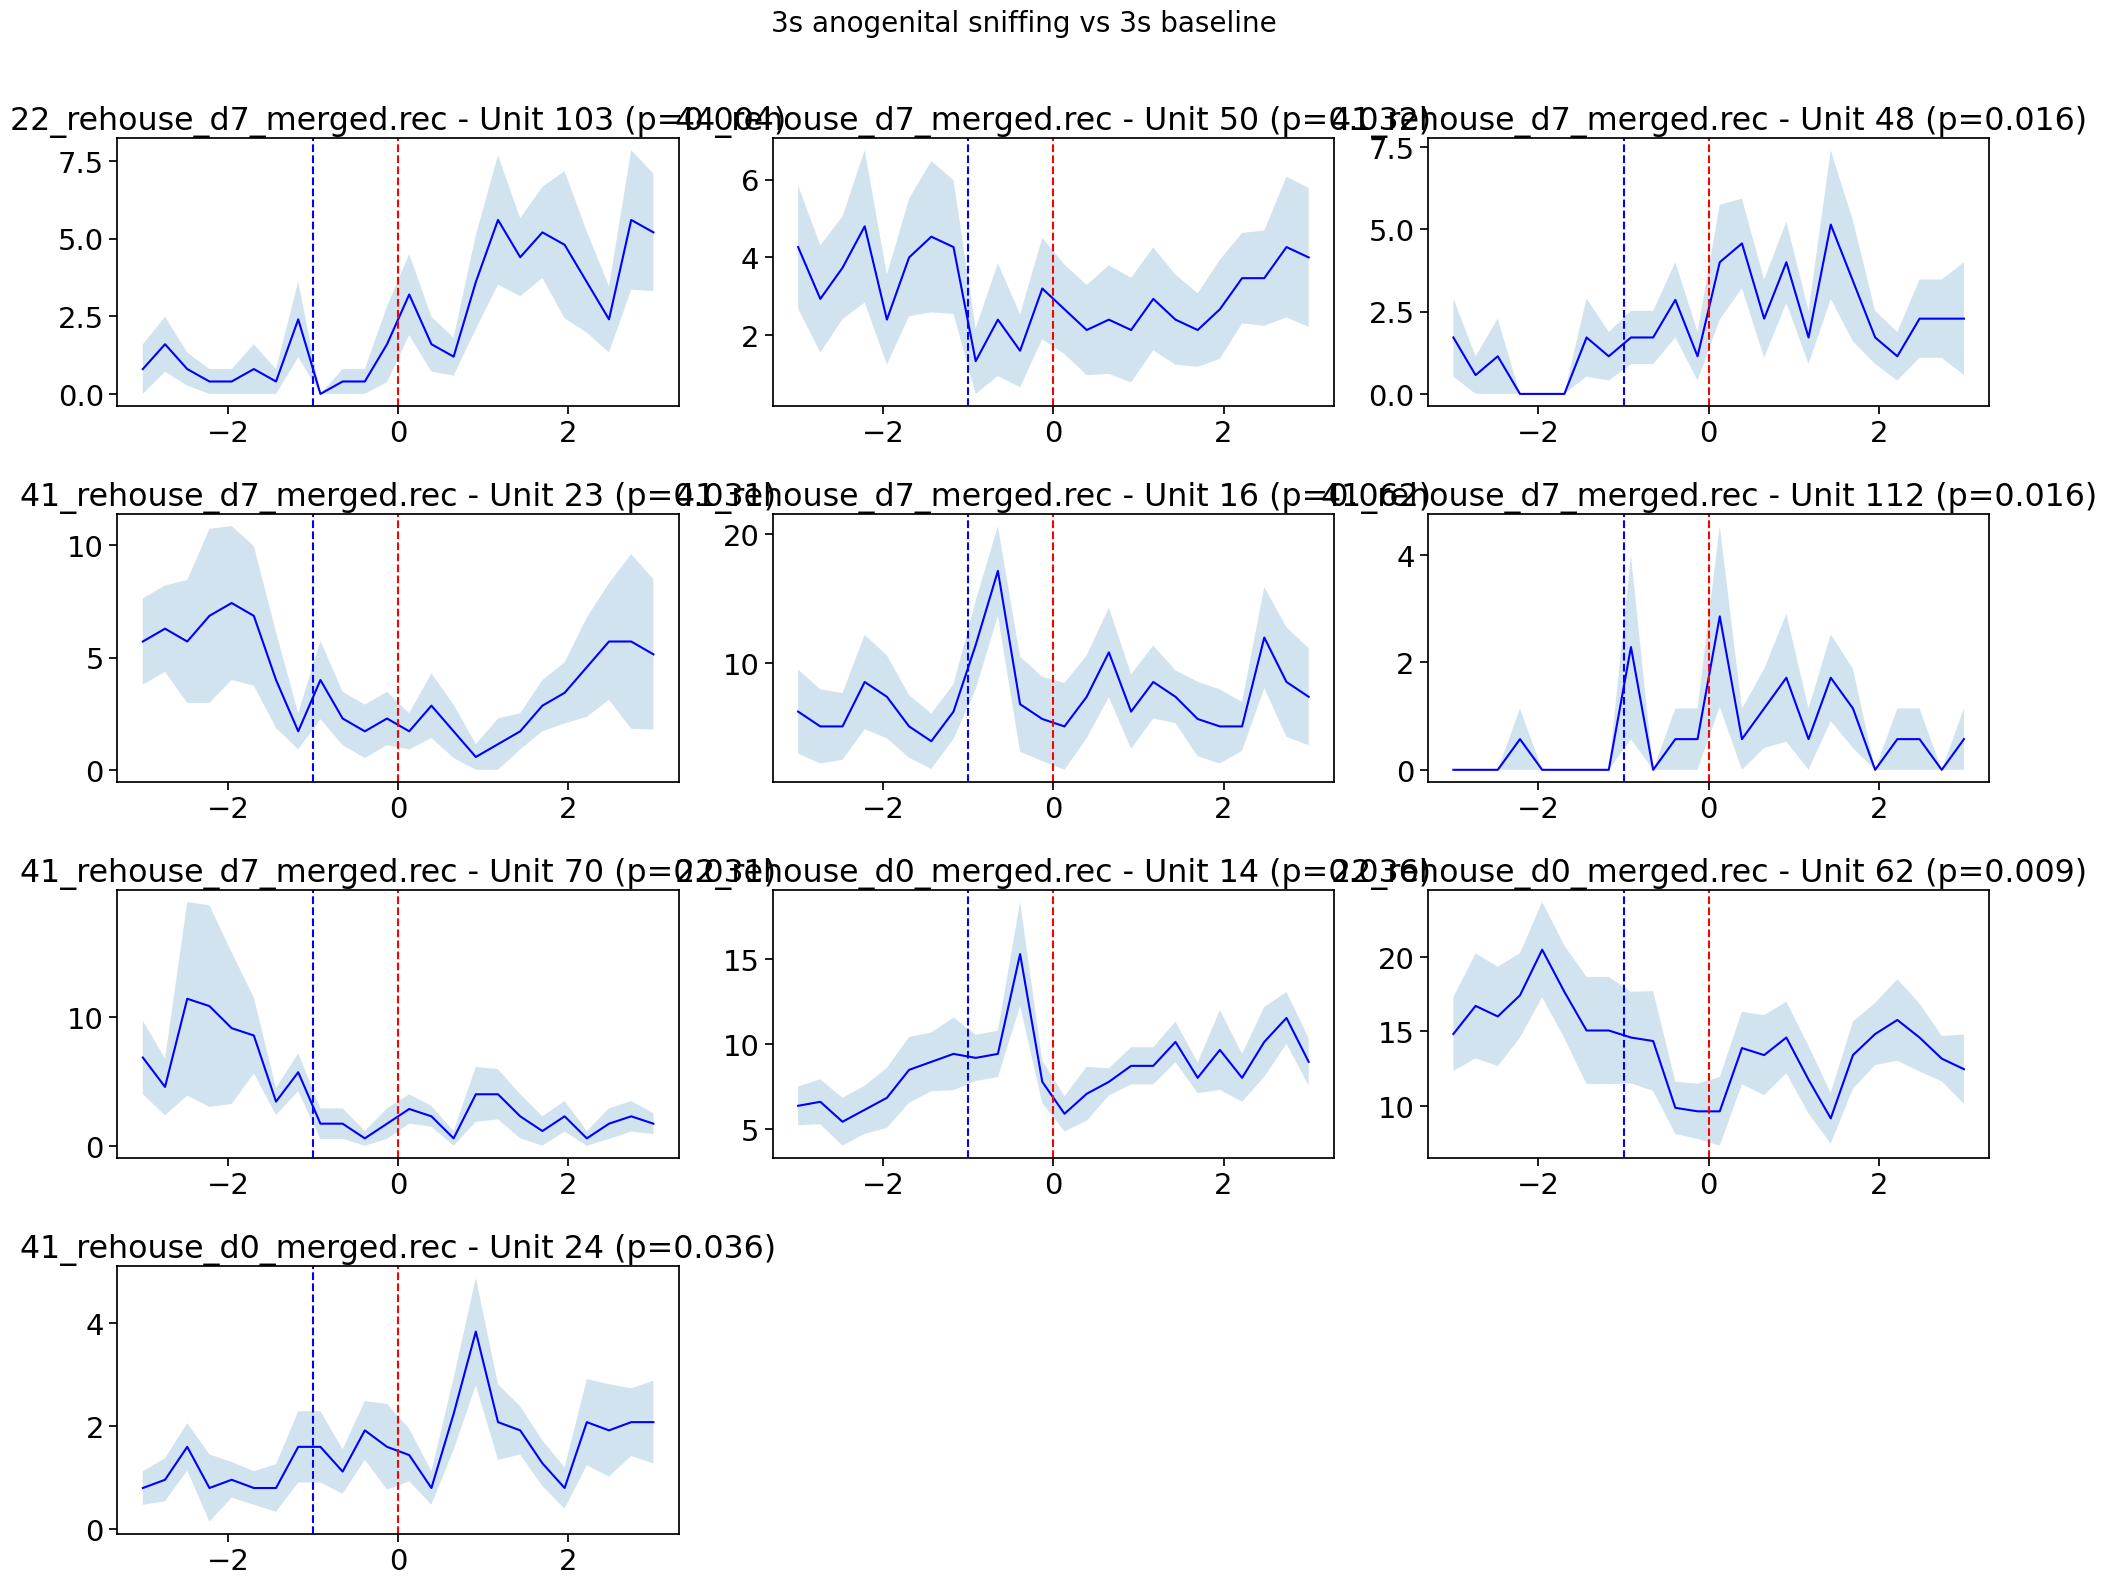

In [40]:
ano_wilcox = single_cell.wilcoxon_collection(spike_collection=sc,
                                event = 'anogenital sniffing', #name of event used in the event_dict
                                event_length = 3, # in seconds
                                baseline_window=3, # in seconds
                                offset=-1,
                                plot = True)

In [55]:
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

# Clean warning output
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

def create_upset_plot_within_day(df, day='d0', significance_type='both', title=None):
    """
    Create a styled UpSet plot showing overlap between events within a single day,
    formatted for clean top/bottom spacing.
    """

    # -------------------------------
    # Setup
    # -------------------------------
    exclude_events = ['mice back in', 'mice taken out']
    all_events = sorted(set(df['Event'].unique()) - set(exclude_events))
    event_sets = {}

    # -------------------------------
    # Build event sets by significance
    # -------------------------------
    for event in all_events:
        event_df = df[df['Event'] == event]

        if significance_type == 'both':
            filtered_df = event_df[event_df['sig'].isin(['increase', 'decrease'])]
        elif significance_type == 'all':
            filtered_df = event_df
        else:
            filtered_df = event_df[event_df['sig'] == significance_type]

        identifiers = [f"{row['Recording']}_Unit{row['Unit']}" for _, row in filtered_df.iterrows()]
        if identifiers:
            event_sets[event] = set(identifiers)

    if not event_sets:
        print(f"No data to plot for {day}")
        return None, None

    # -------------------------------
    # Convert and style
    # -------------------------------
    data = from_contents(event_sets)
    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_alpha(0.0)

    upset = UpSet(
        data,
        subset_size='count',
        show_counts=True,
        sort_by='cardinality',
        element_size=32,
        intersection_plot_elements=6,
    )

    # Choose consistent colors
    color = globals().get('COLOR_DAY0', '#4A90E2') if day == 'd0' else globals().get('COLOR_DAY7', '#E24A4A')
    upset.style_subsets(
        present=list(event_sets.keys()),
        facecolor=color,
        edgecolor='black',
        linewidth=1.5,
    )

    # -------------------------------
    # Plot and format
    # -------------------------------
    upset.plot(fig=fig)

    for ax in fig.get_axes():
        ax.set_facecolor('none')
        sns.despine(ax=ax)
        ax.tick_params(width=1.5, length=6, labelsize=14)

    # -------------------------------
    # Titles and annotations
    # -------------------------------
    sig_text = {
        'both': 'Significant Units (↑ o',
        'increase': 'Increasing Units',
        'decrease': 'Decreasing Units',
        'all': 'All Units'
    }
    if title is None:
        title = f"Significant Unit Overlap Across Events and Days {day.upper()}"

    # Add more padding for the title
    plt.suptitle(title, fontsize=22, y=1.08, fontweight='bold')

    # Add annotation with bottom padding space
    all_units = set().union(*event_sets.values())
    plt.figtext(0.02, 0.015, f"Total unique units: {len(all_units)}",
                fontsize=18, ha='left', fontweight='bold')

    # -------------------------------
    # Adjust subplot margins for clean spacing
    # -------------------------------
    plt.subplots_adjust(
        top=0.90,   # more space for title
        bottom=0.06,  # more space for annotation
        left=0.08,   # ensure y-axis label doesn’t collide
        right=0.95   # keep consistent with wide aspect
    )

    plt.show()
    return event_sets, all_units


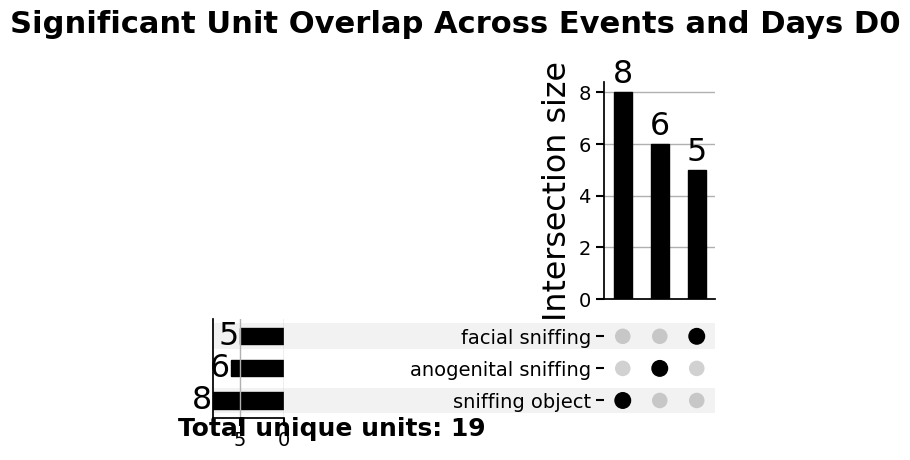

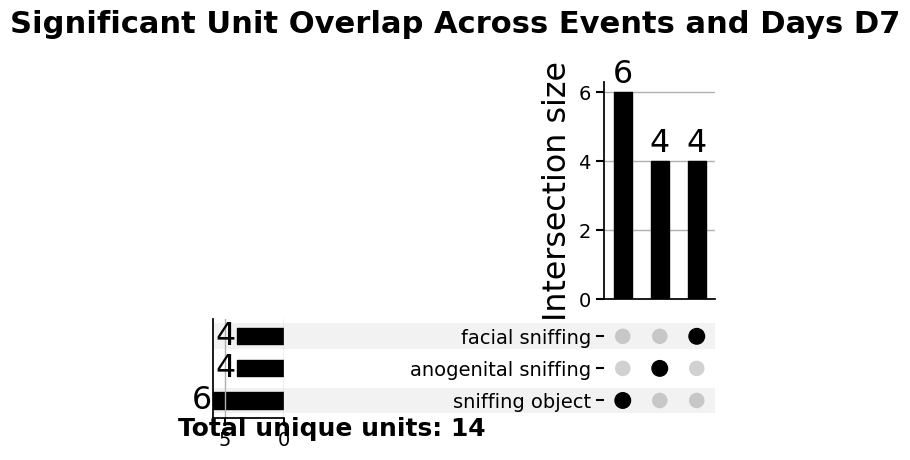

In [56]:
event_sets_d0, units_d0 = create_upset_plot_within_day(df_d0_full, day='d0', significance_type='both')
event_sets_d7, units_d7 = create_upset_plot_within_day(df_d7_full, day='d7', significance_type='both')


In [45]:
all_events = sorted(wilcoxon_df["event"].unique())  # or however you store event names

plot_all_events_split(
    spike_collection=sc,                 # your SpikeCollection instance
    all_wilcoxon_results=all_wilcoxon_results,
    event_list=all_events,
    event_length=3,
    baseline_window=3,
    offset=0,
    save_dir=SAVE_DIR
)


NameError: name 'plot_all_events_split' is not defined